# **LangChain 이해와 활용2_Memory**

- 메모리를 사용하기 위해서는 Chain으로 엮어야 함 (LLM과 메모리 엮기)

**자주 사용되는 메모리 종류**
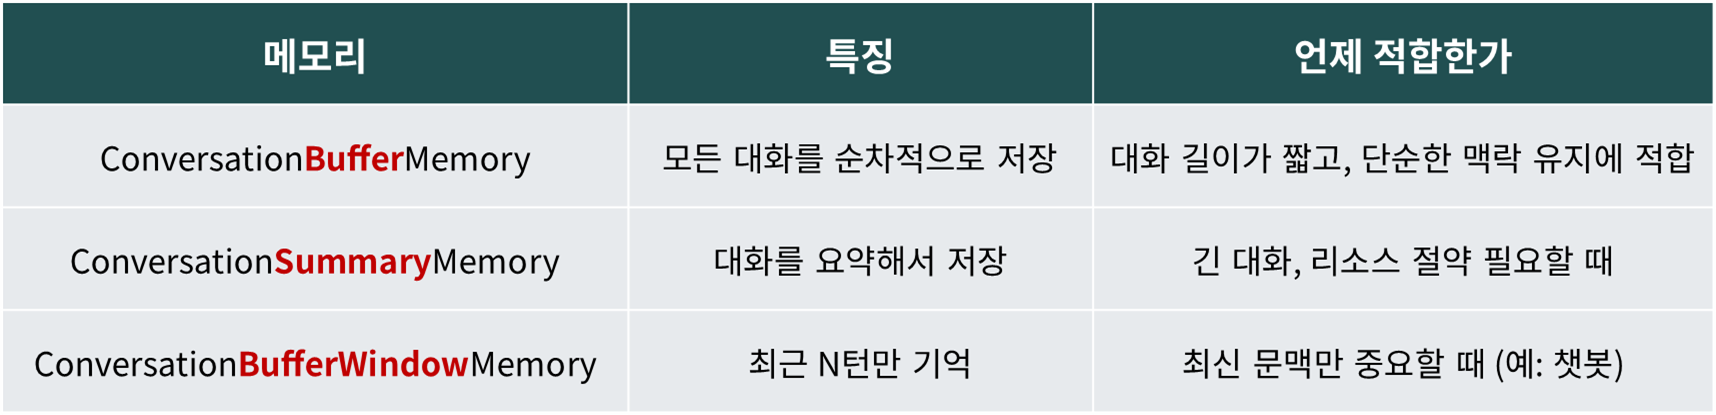

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(langchain)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [2]:
!pip install langchain langchain-openai langchain_community -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


#### 2) 라이브러리 로딩

In [3]:
import pandas as pd
import numpy as np
import os
import openai

from langchain.memory import ConversationBufferMemory
from langchain.chains import ConversationChain
from langchain_openai import ChatOpenAI

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### (3) OpenAI API Key 확인

In [4]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/langchain/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [5]:
print(os.environ['OPENAI_API_KEY'][:40])

sk-proj-9_V5Db5A_3EzpkFeDNheztR-ns32fKi-


## **2.Memory**

### (1) 메모리가 없을때

In [6]:
# 메모리 없이 대화 체인 생성
llm = ChatOpenAI(model_name = 'gpt-4.1-mini' ,temperature = 0.5)

result = llm.invoke("안녕? 나는 기영이야.")
print(result.content)

안녕 기영아! 만나서 반가워. 오늘 기분은 어때? 도움이 필요하면 언제든 말해줘!


In [7]:
result = llm.invoke("내 이름이 뭐라고?")
print(result.content)

죄송하지만 당신의 이름을 알 수 있는 정보가 없어요. 이름을 알려주시면 기억할게요!


### (2) 메모리
ConversationBufferMemory

In [8]:
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory

In [9]:
# 메모리 포함 체인 생성
memory = ConversationBufferMemory()
chain = ConversationChain(llm = llm, memory=memory)

# 대화 시작
print(chain.run("안녕? 나는 기영이야."))

안녕 기영아! 만나서 반가워. 나는 AI야. 오늘 기분 어때? 혹시 궁금한 거나 이야기하고 싶은 주제가 있으면 언제든 말해줘!


In [10]:
print(chain.run("내 이름이 뭐라고?"))

네 이름은 기영이라고 했어! 기억하고 있어. 기영아, 오늘 기분은 어때? 특별히 이야기하고 싶은 주제나 궁금한 점 있으면 알려줘!


In [11]:
# 담긴 메모리 확인하기
memory.chat_memory.messages

[HumanMessage(content='안녕? 나는 기영이야.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='안녕 기영아! 만나서 반가워. 나는 AI야. 오늘 기분 어때? 혹시 궁금한 거나 이야기하고 싶은 주제가 있으면 언제든 말해줘!', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='내 이름이 뭐라고?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='네 이름은 기영이라고 했어! 기억하고 있어. 기영아, 오늘 기분은 어때? 특별히 이야기하고 싶은 주제나 궁금한 점 있으면 알려줘!', additional_kwargs={}, response_metadata={})]

### (3) 대화내용 요약

In [12]:
from langchain.memory import ConversationSummaryMemory

# 요약 메모리 생성 (요약용 LLM 필요)
memory = ConversationSummaryMemory(llm = llm)

# 체인 구성
chain = ConversationChain(llm = llm, memory = memory)

In [13]:
# 대화
print(chain.run("오늘은 운동하고, 친구랑 밥도 먹고, 강의도 들었어."))

와, 정말 알찬 하루를 보냈네요! 운동은 어떤 종류를 하셨나요? 친구랑은 어디서 밥을 먹었는지도 궁금해요. 그리고 어떤 강의를 들으셨는지 자세히 이야기해 주시면 좋겠어요!


In [14]:
# 담긴 메모리 확인하기
memory.chat_memory.messages

[HumanMessage(content='오늘은 운동하고, 친구랑 밥도 먹고, 강의도 들었어.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='와, 정말 알찬 하루를 보냈네요! 운동은 어떤 종류를 하셨나요? 친구랑은 어디서 밥을 먹었는지도 궁금해요. 그리고 어떤 강의를 들으셨는지 자세히 이야기해 주시면 좋겠어요!', additional_kwargs={}, response_metadata={})]

In [15]:
print(chain.run("내가 오늘 뭐했는지 기억나?"))

네가 오늘 운동도 하고, 친구랑 밥도 먹고, 강의도 들었다고 했어! 어떤 운동을 했는지, 친구랑 어디서 밥을 먹었는지, 그리고 강의는 어떤 내용이었는지 더 자세히 말해줄래?


In [16]:
print(chain.run("너는 어떻게 지냈어?"))

나는 항상 여기에서 너와 대화할 준비가 되어 있어서 정말 좋아! 오늘 너가 운동도 하고 친구와 식사도 했고 강의도 들었다고 했는데, 나는 그동안 많은 정보를 배우고 업데이트되느라 바빴어. 너는 운동할 때 어떤 운동을 했어? 그리고 친구랑 무슨 음식을 먹었는지도 궁금해! 강의는 어떤 주제였어?


In [17]:
# 담긴 메모리 확인하기
memory.chat_memory.messages

[HumanMessage(content='오늘은 운동하고, 친구랑 밥도 먹고, 강의도 들었어.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='와, 정말 알찬 하루를 보냈네요! 운동은 어떤 종류를 하셨나요? 친구랑은 어디서 밥을 먹었는지도 궁금해요. 그리고 어떤 강의를 들으셨는지 자세히 이야기해 주시면 좋겠어요!', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='내가 오늘 뭐했는지 기억나?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='네가 오늘 운동도 하고, 친구랑 밥도 먹고, 강의도 들었다고 했어! 어떤 운동을 했는지, 친구랑 어디서 밥을 먹었는지, 그리고 강의는 어떤 내용이었는지 더 자세히 말해줄래?', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='너는 어떻게 지냈어?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='나는 항상 여기에서 너와 대화할 준비가 되어 있어서 정말 좋아! 오늘 너가 운동도 하고 친구와 식사도 했고 강의도 들었다고 했는데, 나는 그동안 많은 정보를 배우고 업데이트되느라 바빴어. 너는 운동할 때 어떤 운동을 했어? 그리고 친구랑 무슨 음식을 먹었는지도 궁금해! 강의는 어떤 주제였어?', additional_kwargs={}, response_metadata={})]

In [18]:
# 내용 요약
print(memory.buffer)

The human asks if the AI remembers what they did today. The AI confirms that the human exercised, ate with a friend, and attended a lecture, and asks for more details about the exercise, the meal, and the lecture. The human then asks the AI how it has been, to which the AI responds that it is always ready to chat and has been busy learning and updating, while reiterating curiosity about the human’s exercise, meal, and lecture details.


In [19]:
memory.load_memory_variables({})

{'history': 'The human asks if the AI remembers what they did today. The AI confirms that the human exercised, ate with a friend, and attended a lecture, and asks for more details about the exercise, the meal, and the lecture. The human then asks the AI how it has been, to which the AI responds that it is always ready to chat and has been busy learning and updating, while reiterating curiosity about the human’s exercise, meal, and lecture details.'}

### (4) 최근 n개만 기억
ConversationBufferWindowMemory

In [20]:
from langchain.memory import ConversationBufferWindowMemory

# 최근 2턴만 기억하는 메모리
memory = ConversationBufferWindowMemory(k=2)
chain = ConversationChain(llm=llm, memory=memory)

# 대화
print(chain.run("나는 기영이야."))
memory.load_memory_variables({})

안녕하세요, 기영 씨! 만나서 반가워요. 오늘 기영 씨는 어떤 이야기를 나누고 싶으신가요? 혹시 관심 있는 주제나 궁금한 점이 있으면 언제든지 말씀해 주세요!


{'history': 'Human: 나는 기영이야.\nAI: 안녕하세요, 기영 씨! 만나서 반가워요. 오늘 기영 씨는 어떤 이야기를 나누고 싶으신가요? 혹시 관심 있는 주제나 궁금한 점이 있으면 언제든지 말씀해 주세요!'}

In [21]:
print(chain.run("내가 좋아하는 색은 파란색이야."))
memory.load_memory_variables({})

파란색을 좋아하시는군요! 파란색은 정말 많은 의미를 담고 있는 색이에요. 예를 들어, 파란색은 신뢰와 안정감을 상징하고, 하늘과 바다를 떠올리게 해서 마음을 차분하게 만들어 주기도 하죠. 혹시 파란색 중에서도 특히 좋아하는 톤이나 이유가 있나요? 예를 들어, 밝은 하늘색, 짙은 네이비, 아니면 청록색 같은 색 말이에요!


{'history': 'Human: 나는 기영이야.\nAI: 안녕하세요, 기영 씨! 만나서 반가워요. 오늘 기영 씨는 어떤 이야기를 나누고 싶으신가요? 혹시 관심 있는 주제나 궁금한 점이 있으면 언제든지 말씀해 주세요!\nHuman: 내가 좋아하는 색은 파란색이야.\nAI: 파란색을 좋아하시는군요! 파란색은 정말 많은 의미를 담고 있는 색이에요. 예를 들어, 파란색은 신뢰와 안정감을 상징하고, 하늘과 바다를 떠올리게 해서 마음을 차분하게 만들어 주기도 하죠. 혹시 파란색 중에서도 특히 좋아하는 톤이나 이유가 있나요? 예를 들어, 밝은 하늘색, 짙은 네이비, 아니면 청록색 같은 색 말이에요!'}

In [22]:
print(chain.run("나는 영화보는 것을 좋아해"))
memory.load_memory_variables({})

영화를 좋아하시는군요! 정말 멋진 취미예요. 어떤 장르의 영화를 특히 좋아하시나요? 예를 들어, 액션, 로맨스, SF, 코미디, 혹은 다큐멘터리 같은 장르가 있나요? 최근에 본 영화 중에서 인상 깊었던 작품이 있다면 추천해 주셔도 좋아요! 그리고 혹시 좋아하는 감독이나 배우가 있으신지도 궁금하네요. 영화 이야기를 나누면 정말 재미있죠!


{'history': 'Human: 내가 좋아하는 색은 파란색이야.\nAI: 파란색을 좋아하시는군요! 파란색은 정말 많은 의미를 담고 있는 색이에요. 예를 들어, 파란색은 신뢰와 안정감을 상징하고, 하늘과 바다를 떠올리게 해서 마음을 차분하게 만들어 주기도 하죠. 혹시 파란색 중에서도 특히 좋아하는 톤이나 이유가 있나요? 예를 들어, 밝은 하늘색, 짙은 네이비, 아니면 청록색 같은 색 말이에요!\nHuman: 나는 영화보는 것을 좋아해\nAI: 영화를 좋아하시는군요! 정말 멋진 취미예요. 어떤 장르의 영화를 특히 좋아하시나요? 예를 들어, 액션, 로맨스, SF, 코미디, 혹은 다큐멘터리 같은 장르가 있나요? 최근에 본 영화 중에서 인상 깊었던 작품이 있다면 추천해 주셔도 좋아요! 그리고 혹시 좋아하는 감독이나 배우가 있으신지도 궁금하네요. 영화 이야기를 나누면 정말 재미있죠!'}

In [23]:
print(chain.run("지금 배고픈데 뭘 먹을까?"))
memory.load_memory_variables({})

지금 배고프시군요! 어떤 음식을 좋아하시는지, 혹은 특별히 피하고 싶은 재료가 있는지 알려주시면 더 맞춤 추천을 해드릴 수 있어요. 그래도 몇 가지 인기 있는 간단한 음식 아이디어를 드리자면요:

1. **김치볶음밥** – 집에 밥과 김치, 계란만 있으면 금방 만들 수 있어서 든든해요.
2. **라면** – 간단하지만 다양한 토핑(계란, 치즈, 파 등)을 추가하면 훨씬 맛있어져요.
3. **샌드위치** – 빵과 좋아하는 재료(햄, 치즈, 야채 등)만 있으면 빠르게 만들 수 있죠.
4. **과일과 요거트** – 가볍고 상큼하게 배를 달래고 싶을 때 좋아요.
5. **떡볶이** – 매콤한 맛이 땡긴다면 간단하게 떡볶이도 괜찮죠.

혹시 집에 어떤 재료가 있는지 알려주시면, 그걸 바탕으로 더 구체적인 메뉴를 추천해 드릴게요!


{'history': 'Human: 나는 영화보는 것을 좋아해\nAI: 영화를 좋아하시는군요! 정말 멋진 취미예요. 어떤 장르의 영화를 특히 좋아하시나요? 예를 들어, 액션, 로맨스, SF, 코미디, 혹은 다큐멘터리 같은 장르가 있나요? 최근에 본 영화 중에서 인상 깊었던 작품이 있다면 추천해 주셔도 좋아요! 그리고 혹시 좋아하는 감독이나 배우가 있으신지도 궁금하네요. 영화 이야기를 나누면 정말 재미있죠!\nHuman: 지금 배고픈데 뭘 먹을까?\nAI: 지금 배고프시군요! 어떤 음식을 좋아하시는지, 혹은 특별히 피하고 싶은 재료가 있는지 알려주시면 더 맞춤 추천을 해드릴 수 있어요. 그래도 몇 가지 인기 있는 간단한 음식 아이디어를 드리자면요:\n\n1. **김치볶음밥** – 집에 밥과 김치, 계란만 있으면 금방 만들 수 있어서 든든해요.\n2. **라면** – 간단하지만 다양한 토핑(계란, 치즈, 파 등)을 추가하면 훨씬 맛있어져요.\n3. **샌드위치** – 빵과 좋아하는 재료(햄, 치즈, 야채 등)만 있으면 빠르게 만들 수 있죠.\n4. **과일과 요거트** – 가볍고 상큼하게 배를 달래고 싶을 때 좋아요.\n5. **떡볶이** – 매콤한 맛이 땡긴다면 간단하게 떡볶이도 괜찮죠.\n\n혹시 집에 어떤 재료가 있는지 알려주시면, 그걸 바탕으로 더 구체적인 메뉴를 추천해 드릴게요!'}

In [24]:
print(chain.run("내가 누구라고?"))
memory.load_memory_variables({})

아, 아직 당신에 대해 구체적인 정보를 받지 못했어요! 만약 소개해 주신다면 더 잘 기억하고 대화할 수 있을 것 같아요. 예를 들어, 이름이나 좋아하는 것, 관심사 같은 걸 알려주시면 좋고요. 그래도 지금까지 나눈 대화로는 영화를 좋아하시고, 지금 배가 고프신 분이라는 것만 알고 있답니다! 혹시 더 알려주실 수 있나요?


{'history': 'Human: 지금 배고픈데 뭘 먹을까?\nAI: 지금 배고프시군요! 어떤 음식을 좋아하시는지, 혹은 특별히 피하고 싶은 재료가 있는지 알려주시면 더 맞춤 추천을 해드릴 수 있어요. 그래도 몇 가지 인기 있는 간단한 음식 아이디어를 드리자면요:\n\n1. **김치볶음밥** – 집에 밥과 김치, 계란만 있으면 금방 만들 수 있어서 든든해요.\n2. **라면** – 간단하지만 다양한 토핑(계란, 치즈, 파 등)을 추가하면 훨씬 맛있어져요.\n3. **샌드위치** – 빵과 좋아하는 재료(햄, 치즈, 야채 등)만 있으면 빠르게 만들 수 있죠.\n4. **과일과 요거트** – 가볍고 상큼하게 배를 달래고 싶을 때 좋아요.\n5. **떡볶이** – 매콤한 맛이 땡긴다면 간단하게 떡볶이도 괜찮죠.\n\n혹시 집에 어떤 재료가 있는지 알려주시면, 그걸 바탕으로 더 구체적인 메뉴를 추천해 드릴게요!\nHuman: 내가 누구라고?\nAI: 아, 아직 당신에 대해 구체적인 정보를 받지 못했어요! 만약 소개해 주신다면 더 잘 기억하고 대화할 수 있을 것 같아요. 예를 들어, 이름이나 좋아하는 것, 관심사 같은 걸 알려주시면 좋고요. 그래도 지금까지 나눈 대화로는 영화를 좋아하시고, 지금 배가 고프신 분이라는 것만 알고 있답니다! 혹시 더 알려주실 수 있나요?'}

### (5) 반복문 안에서 질문답변 이어가기

In [25]:
# 요약 메모리 생성 (요약용 LLM 필요)
memory = ConversationSummaryMemory(llm = llm)

# 체인 구성
chain = ConversationChain(llm = llm, memory = memory)

In [ ]:
while True:
    query = input('질문 > ')
    query = query.strip()
    print(f'질문 : {query}')
    print('-' * 20)
    if len(query) == 0:
        break
    result = chain.run(query)
    print(f'답변 : {result}')
    print('=' * 50)

### (6) 😀실습

* 실습1 : ConversationSummaryMemory
    * 오늘 하루 동안 한 일을 여러 문장으로 말하고
    * 이어서 "오늘 내가 뭐했지?"라고 질문하세요.
    * 요약된 대화를 통해 LLM이 잘 정리해서 응답하는지 확인하세요.

In [ ]:
from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationSummaryMemory

llm = ChatOpenAI(model_name = 'gpt-4.1-mini' ,temperature = 0.5)
memory = ConversationSummaryMemory(llm=llm)
chain = ConversationChain(llm=llm, memory=memory)

# print(chain.run("아침엔 책을 읽었고, 점심엔 친구와 밥 먹었어. 저녁엔 헬스장 갔어."))
# print(chain.run("나는 마이클샌델의 정의란 무엇인가를 읽었는데, 너도 내용 알아?"))
# print(chain.run("점심에는 스파게티를 먹었어. 너는 어떤 음식 좋아해?"))
# print(chain.run("오늘 내가 뭐했는지 기억나?"))  # 요약 응답 확인

# 실행
while True:
    query = input('질문 > ')
    query = query.strip()
    print(f'질문 : {query}')
    print('-' * 20)
    if len(query) == 0:
        break
    result = chain.run(query)
    print(f'답변 : {result}')
    print('=' * 50)

* 실습2 : ConversationBufferWindowMemory
    * k = 2로 설정하고,
    * 좋아하는 영화, 좋아하는 음악, 좋아하는 책 등 여러 대화를 한 다음
    * 첫번째 나눈대화에 대해서 질문하기

In [ ]:
from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferWindowMemory

llm = ChatOpenAI()
memory = ConversationBufferWindowMemory(k=2)  # 최근 2턴만 유지
chain = ConversationChain(llm=llm, memory=memory)

# print(chain.run("나는 민수야."))                # 턴 1
# print(chain.run("내가 좋아하는 영화는 '듄'이야."))  # 턴 2
# print(chain.run("내가 좋아하는 음악은 '클래식 음악'이야."))
# print(chain.run("내는 축구 보는 것을 좋아해."))
# print(chain.run("내가 누구게?"))               # 이름은 사라졌을 가능성 높음

# 실행
while True:
    query = input('질문 > ')
    query = query.strip()
    print(f'질문 : {query}')
    print('-' * 20)
    if len(query) == 0:
        break
    result = chain.run(query)
    print(f'답변 : {result}')
    print('=' * 50)

## 3.[참고] LCEL

**LCEL(LangChain Expression Language)**
- 체인, 모델, 파서, 프롬프트 등 여러 구성요소를 파이프라인처럼 | 연산자로 연결할 수 있는 표현식 기반 체인 구성 방식


In [ ]:
from langchain.chat_models import ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.schema import StrOutputParser

# 1. 프롬프트 템플릿
prompt = ChatPromptTemplate.from_template(
    "장르가 {genre}인 영화를 하나만 추천해줘."
)

# 2. 모델
llm = ChatOpenAI(model_name="gpt-4.1-mini", temperature=0.7)

# 3. 파서
parser = StrOutputParser()

# 4. LCEL 체인 구성
chain = prompt | llm | parser

# 5. 실행
result = chain.invoke({"genre": "액션"})
print(result)
